In [ ]:
req_pkgs <- c(
  "devtools","ggplot2","dplyr","tidyr","tibble","scales",
  "MASS","numDeriv","matrixStats","purrr","readr","patchwork"
)
need <- setdiff(req_pkgs, rownames(installed.packages()))
if (length(need)) install.packages(need, dependencies = TRUE)
invisible(lapply(req_pkgs, require, character.only = TRUE))

options(warn = 1)
options(error = function() { traceback(2); stop("Stopped on error (see traceback above).", call. = FALSE) })

## --- repo root (works when running from notebooks/) ---
repo_root <- tryCatch(
  normalizePath(system("git rev-parse --show-toplevel", intern = TRUE)),
  error = function(...) normalizePath("..", mustWork = TRUE)
)

to_rm <- intersect(
  c("%||%", ".stopf", "assert_scalar_numeric", "assert_matrix"),
  ls(envir = .GlobalEnv, all.names = TRUE)
)
if (length(to_rm)) rm(list = to_rm, envir = .GlobalEnv)

devtools::load_all(repo_root)
set.seed(12345)
need_funs <- c(
  "qdesn_fit_vb","qdesn_build_design",
  "exal_ldvb_fit","beta_prior",
  "exal_get_ABC"
)

missing <- need_funs[!vapply(need_funs, exists, logical(1), mode = "function", inherits = TRUE)]
if (length(missing)) {
  cat("Missing functions:\n"); print(missing)
  cat("\nObjects matching 'qdesn' in search path:\n")
  print(ls(pattern = "qdesn", all.names = TRUE))
  stop("Required functions missing. load_all() did not expose them.", call. = FALSE)
}

# Optional: if you have L.fn/U.fn in the package, great. If not, we will fallback later.
cat("Has L.fn:", exists("L.fn", mode="function", inherits=TRUE), "\n")
cat("Has U.fn:", exists("U.fn", mode="function", inherits=TRUE), "\n")
data_path <- "/data/muscat_data/jaguir26/exdqlm/results/sim_suite_dlm/series/dlm_constV_smallW/series_long.csv"

df_long <- readr::read_csv(data_path, show_col_types = FALSE)

stopifnot(all(c("t","p","y") %in% names(df_long)))
df_y <- df_long %>%
  arrange(t, p) %>%
  group_by(t) %>%
  summarise(
    y = dplyr::first(y),
    mu_true = dplyr::first(mu),
    .groups = "drop"
  ) %>%
  arrange(t)

y <- df_y$y
T <- length(y)

cat("T =", T, "\n")
print(head(df_y, 3))
print(tail(df_y, 3))

# quick plot
ggplot(df_y, aes(x = t, y = y)) +
  geom_line() +
  labs(title = "Extracted series y(t)", x = "t", y = "y")
p0 <- 0.95

# gamma bounds: prefer your L.fn/U.fn; else use a safe wide interval
gamma_bounds <- if (exists("L.fn", mode="function", inherits=TRUE) &&
                    exists("U.fn", mode="function", inherits=TRUE)) {
  c(L.fn(p0), U.fn(p0))
} else {
  c(-30, 30)
}

# "non-informative" defaults (practical):
# beta: very weak ridge
beta_prior_obj <- beta_prior("ridge", ridge = list(tau2 = 1e8))

# gamma: very wide Normal
prior_gamma <- list(mu0 = 0, s20 = 1e6)

# sigma: weak IG (proper but close to flat on log-scale over a wide range)
prior_sigma <- list(a = 1e-3, b = 1e-3)

vb_control <- list(
  max_iter = 150L,
  tol      = 1e-4,
  tol_par  = 1e-4,
  min_iter_elbo = 100L,
  verbose  = TRUE
)

gamma_bounds
fit_qdesn <- qdesn_fit_vb(
  y = y,
  p0 = p0,

  # keep your defaults unless you want smaller for debugging
  D = 3L,
  n = c(150L, 150L, 150L),
  n_tilde = c(150L, 150L),
  m = 90L,
  alpha = 0.15,
  rho = rep(0.95, 3L),
  act_f = "tanh",
  act_k = "identity",
  pi_w = 0.1,
  pi_in = 0.1,
  washout = 100L,
  add_bias = TRUE,

  seed = 12345,

  vb_args = list(
    # if qdesn_fit_vb forwards these to exal_static_LDVB (old) or exal_ldvb_fit (new)
    vb_control = vb_control,
    gamma_bounds = gamma_bounds,
    prior_gamma = prior_gamma,
    prior_sigma = prior_sigma,
    beta_prior_obj = beta_prior_obj
  ),

  fit_readout = TRUE
)

str(fit_qdesn, max.level = 2)

# If your object stores readout fit as $fit (per header comment):
if (!is.null(fit_qdesn$fit)) {
  cat("Readout converged:", fit_qdesn$fit$converged, " iter:", fit_qdesn$fit$iter, "\n")
  cat("gamma_hat:", fit_qdesn$fit$qsiggam$gamma_mean, " sigma_hat:", fit_qdesn$fit$qsiggam$sigma_mean, "\n")
}
desn_args <- list(
  D = 3L,
  n = c(150L, 150L, 150L),
  n_tilde = c(150L, 150L),
  m = 90L,
  alpha = 0.15,
  rho = rep(0.95, 3L),
  act_f = "tanh",
  act_k = "identity",
  pi_w = 0.1,
  pi_in = 0.1,
  washout = 500L,
  add_bias = TRUE,
  seed = 12345,

  # IMPORTANT: we only want the design here
  fit_readout = FALSE
)


des <- qdesn_build_design(y = y, desn_args = desn_args)
X <- des$X
keep_idx <- des$keep_idx

y_fit <- y[keep_idx]

cat("Design dim:", dim(X), "  y_fit length:", length(y_fit), "\n")
stopifnot(nrow(X) == length(y_fit))

fit_readout <- exal_ldvb_fit(
  y = y_fit,
  X = X,
  p0 = p0,
  gamma_bounds = gamma_bounds,
  vb_control = vb_control,
  init = list(),                 # keep default init
  prior_gamma = prior_gamma,
  prior_sigma = prior_sigma,
  beta_prior_obj = beta_prior_obj
)

cat("Converged:", fit_readout$converged, " iter:", fit_readout$iter, " time:", fit_readout$run.time, "sec\n")
cat("gamma_hat:", fit_readout$qsiggam$gamma_mean, " sigma_hat:", fit_readout$qsiggam$sigma_mean, "\n")
vb <- fit_readout

df_tr <- tibble::tibble(
  iter = seq_along(vb$misc$elbo_trace),
  elbo = vb$misc$elbo_trace,
  gamma = vb$misc$gamma_trace,
  sigma = vb$misc$sigma_trace,
  new_term = vb$misc$new_term_trace
)

p1 <- ggplot(df_tr, aes(iter, elbo)) + geom_line() + labs(title="ELBO (per obs)")
p2 <- ggplot(df_tr, aes(iter, gamma)) + geom_line() + labs(title="gamma trace")
p3 <- ggplot(df_tr, aes(iter, sigma)) + geom_line() + labs(title="sigma trace")
p4 <- ggplot(df_tr, aes(iter, pmax(new_term, 1e-16))) +
  geom_line() + scale_y_log10() + labs(title="new_term (log10, floored)")

p1 / (p2 | p3) / p4
beta_hat <- vb$qbeta$m
mu_hat <- as.numeric(X %*% beta_hat)

df_fit <- tibble::tibble(
  t = keep_idx,
  y = y_fit,
  mu_hat = mu_hat,
  mu_true = df_y$mu_true[keep_idx]
)

ggplot(df_fit, aes(t, y)) +
  geom_line() +
  geom_line(aes(y = mu_hat)) +
  geom_line(aes(y = mu_true), linetype = 2) +
  labs(title = "y vs fitted mu_hat vs true mu (dashed)", x = "t", y = "")

library(dplyr)
library(ggplot2)
library(tibble)

# Align to the kept time indices (washout dropped)
keep_idx <- fit_qdesn$meta$keep_idx
t_keep   <- keep_idx
y_keep   <- y[keep_idx]

# fitted p0-quantile (location)
mu_hat <- fit_qdesn$mu_hat
if (is.null(mu_hat)) {
  mu_hat <- as.numeric(fit_qdesn$X %*% fit_qdesn$fit$qbeta$m)
}

# optional: true latent mean/quantile from your CSV (you already built df_y with mu_true)
mu_true_keep <- df_y$mu_true[keep_idx]

df_plot <- tibble(
  t = t_keep,
  y = y_keep,
  mu_hat = mu_hat,
  mu_true = mu_true_keep
)

df_last <- df_plot %>% slice_tail(n = 200)

# Overlay plot on last 1000 kept points
ggplot(df_last, aes(x = t)) +
  geom_line(aes(y = y), alpha = 0.6) +
  geom_line(aes(y = mu_hat), linewidth = 1) +
  geom_line(aes(y = mu_true), linetype = 2, alpha = 0.9) +
  labs(
    title = sprintf("Last 1000 points: y vs fitted p0-quantile (p0=%.2f)", p0),
    x = "t", y = ""
  )

# Quick numeric diagnostics on last 1000
check_loss <- function(u, p) u * (p - as.numeric(u < 0))

u <- df_last$y - df_last$mu_hat
cat("MAE:", mean(abs(u)), "\n")
cat("RMSE:", sqrt(mean(u^2)), "\n")
cat("Check loss (pinball):", mean(check_loss(u, p0)), "\n")
cat("Corr(y, mu_hat):", cor(df_last$y, df_last$mu_hat), "\n")

vb <- fit_readout
L <- gamma_bounds[1]; U <- gamma_bounds[2]
gamma_hat <- vb$qsiggam$gamma_mean
sigma_hat <- vb$qsiggam$sigma_mean

cat("dist to bounds:", min(gamma_hat - L, U - gamma_hat), "\n")  # should not be ~0
cat("sigma_hat:", sigma_hat, "\n")

# ELBO should stabilize; small non-monotone wiggles can happen with delta approx,
# but it should not be exploding or going to -Inf/NA.
el <- vb$misc$elbo_trace %||% vb$misc$elbo
cat("ELBO finite:", all(is.finite(el)), "\n")
cat("ELBO last diffs summary:\n"); print(summary(diff(tail(el, 50))))

# Empirical quantile coverage (training)
mu_hat <- as.numeric(X %*% vb$qbeta$m)
cat("coverage P(y <= mu_hat):", mean(y_fit <= mu_hat), " target:", p0, "\n")

# ============== PATCH RHS BUG IN *NAMESPACE* (CURRENT SESSION) ==============

devtools::load_all(repo_root, reset = TRUE)
ns <- asNamespace("exdqlm")

cat("Before patch: typeof(ns$.require_fun('qdesn_rhs_prior_obj')) = ",
    typeof(get(".require_fun", envir = ns)("qdesn_rhs_prior_obj")), "\n")

.require_fun_fixed <- function(fname, pkg = "exdqlm") {
  stopifnot(is.character(fname), length(fname) == 1L, nzchar(fname))

  # Prefer namespace lookup first (this is what package internals should use)
  ns <- tryCatch(asNamespace(pkg), error = function(e) NULL)
  if (!is.null(ns)) {
    fn <- get0(fname, envir = ns, mode = "function", inherits = FALSE)
    if (!is.null(fn)) return(fn)
  }

  # Fallback: search path (useful during development)
  fn <- get0(fname, mode = "function", inherits = TRUE)
  if (!is.null(fn)) return(fn)

  stop(sprintf("Required internal function '%s()' not found.", fname), call. = FALSE)
}

.call_with_supported_args_fixed <- function(fn, ...) {
  if (is.character(fn)) fn <- get(fn, mode = "function", inherits = TRUE)
  if (!is.function(fn)) stop("'.call_with_supported_args': fn is not a function.", call. = FALSE)

  dots <- list(...)
  if (!length(dots)) return(do.call(fn, list()))

  nm <- names(dots)
  if (is.null(nm) || any(nm == "")) return(do.call(fn, dots))

  fmls <- names(formals(fn))
  if (is.null(fmls) || "..." %in% fmls) return(do.call(fn, dots))

  keep <- intersect(nm, fmls)
  do.call(fn, dots[keep])
}

# Patch namespace versions used by beta_prior_rhs()
assignInNamespace(".require_fun", .require_fun_fixed, ns = "exdqlm")
assignInNamespace(".call_with_supported_args", .call_with_supported_args_fixed, ns = "exdqlm")

cat("After patch:  typeof(ns$.require_fun('qdesn_rhs_prior_obj')) = ",
    typeof(get(".require_fun", envir = ns)("qdesn_rhs_prior_obj")),
    "  is.function=",
    is.function(get(".require_fun", envir = ns)("qdesn_rhs_prior_obj")), "\n")

# Smoke test RHS prior construction
rhs_hypers <- list(
  tau0=1.0, nu=4.0, s=1.0,
  shrink_intercept=FALSE, intercept_prec=1e-12,
  n_inner=1L,
  eta_bounds=list(lambda=c(-12,12), tau=c(-12,12), c2=c(-12,12)),
  h_curv=1e-16, var_floor=1e-16,
  verbose=TRUE
)

bp <- beta_prior("rhs", rhs = rhs_hypers)
cat("beta_prior('rhs') class:\n"); print(class(bp))
cat("names(bp):\n"); print(names(bp))
# ================== RHS TEST (readout only, same design) ==================

# 0) reload package code, then re-apply the namespace patch (load_all reset will undo it)
devtools::load_all(repo_root, reset = TRUE)

.require_fun_fixed <- function(fname, pkg = "exdqlm") {
  stopifnot(is.character(fname), length(fname) == 1L, nzchar(fname))
  ns <- tryCatch(asNamespace(pkg), error = function(e) NULL)
  if (!is.null(ns)) {
    fn <- get0(fname, envir = ns, mode = "function", inherits = FALSE)
    if (!is.null(fn)) return(fn)
  }
  fn <- get0(fname, mode = "function", inherits = TRUE)
  if (!is.null(fn)) return(fn)
  stop(sprintf("Required internal function '%s()' not found.", fname), call. = FALSE)
}

.call_with_supported_args_fixed <- function(fn, ...) {
  if (is.character(fn)) fn <- get(fn, mode = "function", inherits = TRUE)
  if (!is.function(fn)) stop("'.call_with_supported_args': fn is not a function.", call. = FALSE)

  dots <- list(...)
  if (!length(dots)) return(do.call(fn, list()))
  nm <- names(dots)
  if (is.null(nm) || any(nm == "")) return(do.call(fn, dots))

  fmls <- names(formals(fn))
  if (is.null(fmls) || "..." %in% fmls) return(do.call(fn, dots))

  keep <- intersect(nm, fmls)
  do.call(fn, dots[keep])
}

assignInNamespace(".require_fun", .require_fun_fixed, ns = "exdqlm")
assignInNamespace(".call_with_supported_args", .call_with_supported_args_fixed, ns = "exdqlm")

ns <- asNamespace("exdqlm")
cat("RHS patch check: typeof(.require_fun('qdesn_rhs_prior_obj')) =",
    typeof(get(".require_fun", envir = ns)("qdesn_rhs_prior_obj")),
    " is.function=", is.function(get(".require_fun", envir = ns)("qdesn_rhs_prior_obj")), "\n")

# 1) RHS prior object
rhs_hypers <- list(
  tau0 = 1.0,
  nu   = 4.0,
  s    = 1.0,
  shrink_intercept = FALSE,
  intercept_prec   = 1e-12,
  n_inner = 1L,
  eta_bounds = list(lambda = c(-12,12), tau = c(-12,12), c2 = c(-12,12)),
  h_curv = 1e-16,
  var_floor = 1e-16,
  verbose = TRUE
)

beta_prior_rhs_obj <- beta_prior("rhs", rhs = rhs_hypers)
cat("beta_prior_rhs_obj class:\n"); print(class(beta_prior_rhs_obj))
stopifnot(is.list(beta_prior_rhs_obj), identical(beta_prior_rhs_obj$type, "rhs"))

# 2) Build the same design you used for ridge
desn_args <- list(
  D = 3L,
  n = c(150L, 150L, 150L),
  n_tilde = c(150L, 150L),
  m = 90L,
  alpha = 0.15,
  rho = rep(0.95, 3L),
  act_f = "tanh",
  act_k = "identity",
  pi_w = 0.1,
  pi_in = 0.1,
  washout = 500L,
  add_bias = TRUE,
  seed = 12345,
  fit_readout = FALSE
)

des <- qdesn_build_design(y = y, desn_args = desn_args)
X <- des$X
keep_idx <- des$keep_idx
y_fit <- y[keep_idx]

cat("Design dim:", paste(dim(X), collapse="x"), " y_fit:", length(y_fit), "\n")
stopifnot(nrow(X) == length(y_fit))

# 3) Fit exAL-LDVB with RHS prior
vb_control <- list(
  max_iter = 150L,
  tol      = 1e-4,
  tol_par  = 1e-4,
  min_iter_elbo = 100L,
  verbose  = TRUE
)

vb_control_rhs <- vb_control
vb_control_rhs$max_iter <- as.integer(vb_control_rhs$max_iter %||% 50L)
vb_control_rhs$verbose  <- TRUE

fit_rhs <- exal_ldvb_fit(
  y = y_fit,
  X = X,
  p0 = p0,
  gamma_bounds = gamma_bounds,
  vb_control   = vb_control_rhs,
  init         = list(),
  prior_gamma  = prior_gamma,
  prior_sigma  = prior_sigma,
  beta_prior_obj = beta_prior_rhs_obj
)

cat("RHS converged:", fit_rhs$converged, " iter:", fit_rhs$iter, " time:", fit_rhs$run.time, "sec\n")
cat("RHS gamma_hat:", fit_rhs$qsiggam$gamma_mean, " sigma_hat:", fit_rhs$qsiggam$sigma_mean, "\n")

# 4) Basic traces + quick fit diagnostics
vb <- fit_rhs
el <- vb$misc$elbo_trace %||% vb$misc$elbo
cat("ELBO finite:", all(is.finite(el)), "  last(elbo):", tail(el, 1), "\n")
cat("gamma last:", tail(vb$misc$gamma_trace, 1), " sigma last:", tail(vb$misc$sigma_trace, 1), "\n")

beta_hat_rhs <- vb$qbeta$m
mu_hat_rhs <- as.numeric(X %*% beta_hat_rhs)

check_loss <- function(u, p) u * (p - as.numeric(u < 0))
u <- y_fit - mu_hat_rhs

cat("RHS coverage P(y<=mu_hat):", mean(y_fit <= mu_hat_rhs), " target:", p0, "\n")
cat("RHS pinball:", mean(check_loss(u, p0)), "  MAE:", mean(abs(u)), "  RMSE:", sqrt(mean(u^2)), "\n")

cat("RHS |beta| summary:\n"); print(summary(abs(as.numeric(beta_hat_rhs))))
## ================== RHS diagnostics (NO refit) ==================

suppressPackageStartupMessages({
  library(ggplot2); library(dplyr); library(tibble); library(patchwork); library(scales)
})

`%||%` <- function(x, y) if (!is.null(x)) x else y

# --- pick the VB fit object you want to diagnose ---
vb <- if (exists("fit_rhs")) {
  fit_rhs
} else if (exists("fit_readout")) {
  fit_readout
} else if (exists("fit_qdesn") && !is.null(fit_qdesn$fit)) {
  fit_qdesn$fit
} else {
  stop("Could not find a fit object. Expected fit_rhs, fit_readout, or fit_qdesn$fit.", call. = FALSE)
}

# --- locate design + data (assumes you already built these in your run) ---
if (!exists("X")) {
  if (exists("fit_qdesn") && !is.null(fit_qdesn$X)) X <- fit_qdesn$X
  else stop("X not found in workspace.", call. = FALSE)
}
if (!exists("keep_idx")) {
  if (exists("des") && !is.null(des$keep_idx)) keep_idx <- des$keep_idx
  else if (exists("fit_qdesn") && !is.null(fit_qdesn$meta$keep_idx)) keep_idx <- fit_qdesn$meta$keep_idx
  else stop("keep_idx not found in workspace.", call. = FALSE)
}
if (!exists("y_fit")) {
  if (exists("y")) y_fit <- y[keep_idx]
  else stop("y_fit not found and y not found.", call. = FALSE)
}

stopifnot(nrow(X) == length(y_fit))

p0 <- get0("p0", ifnotfound = NA_real_)
if (!is.finite(p0)) message("Note: p0 not found. Coverage/pinball will be NA unless you define p0.")

# --- ELBO + parameter traces ---
elbo <- vb$misc$elbo_trace %||% vb$misc$elbo
if (is.null(elbo)) stop("No ELBO trace found at vb$misc$elbo_trace or vb$misc$elbo.", call. = FALSE)

get_tr <- function(nm, n) {
  x <- vb$misc[[nm]]
  if (is.null(x)) rep(NA_real_, n) else as.numeric(x)
}

df_tr <- tibble(
  iter = seq_along(elbo),
  elbo = as.numeric(elbo),
  gamma = get_tr("gamma_trace", length(elbo)),
  sigma = get_tr("sigma_trace", length(elbo)),
  new_term = get_tr("new_term_trace", length(elbo))
)

p_elbo <- ggplot(df_tr, aes(iter, elbo)) + geom_line() +
  labs(title = "ELBO trace", x = "iter", y = "ELBO")
p_gam <- ggplot(df_tr, aes(iter, gamma)) + geom_line() +
  labs(title = "gamma trace", x = "iter", y = "gamma")
p_sig <- ggplot(df_tr, aes(iter, sigma)) + geom_line() +
  labs(title = "sigma trace", x = "iter", y = "sigma")
p_new <- ggplot(df_tr, aes(iter, pmax(new_term, 1e-16))) + geom_line() +
  scale_y_log10(labels = label_scientific()) +
  labs(title = "new_term (log10)", x = "iter", y = "new_term")

(p_elbo / (p_gam | p_sig) / p_new)

cat("ELBO finite:", all(is.finite(df_tr$elbo)), "\n")
cat("ELBO last diffs (last 50 iters):\n"); print(summary(diff(tail(df_tr$elbo, 50))))

# --- fitted mu_hat and comparison to y / mu_true (if available) ---
beta_hat <- as.numeric(vb$qbeta$m)
mu_hat <- as.numeric(X %*% beta_hat)

mu_true_keep <- rep(NA_real_, length(y_fit))
if (exists("df_y") && is.data.frame(df_y) && "mu_true" %in% names(df_y)) {
  mu_true_keep <- df_y$mu_true[keep_idx]
}

df_fit <- tibble(
  t = keep_idx,
  y = y_fit,
  mu_hat = mu_hat,
  mu_true = mu_true_keep
)

n_last <- 200L
df_last <- df_fit %>% slice_tail(n = n_last)

p_last <- ggplot(df_last, aes(x = t)) +
  geom_line(aes(y = y), alpha = 0.6) +
  geom_line(aes(y = mu_hat), linewidth = 1) +
  { if (any(is.finite(df_last$mu_true))) geom_line(aes(y = mu_true), linetype = 2, alpha = 0.9) } +
  labs(title = sprintf("Last %d kept points: y vs mu_hat%s", n_last,
                       if (any(is.finite(df_last$mu_true))) " vs mu_true (dashed)" else ""),
       x = "t", y = "")

p_full <- ggplot(df_fit, aes(x = t)) +
  geom_line(aes(y = y), alpha = 0.5) +
  geom_line(aes(y = mu_hat), linewidth = 0.8) +
  { if (any(is.finite(df_fit$mu_true))) geom_line(aes(y = mu_true), linetype = 2, alpha = 0.7) } +
  labs(title = "All kept points: y vs mu_hat", x = "t", y = "")

(p_full / p_last)

# --- optional: uncertainty band for mu from q(beta) (NOT predictive) ---
if (!is.null(vb$qbeta$V) && is.matrix(vb$qbeta$V)) {
  Vb <- vb$qbeta$V
  # sd(mu_i) = sqrt(x_i^T V x_i)
  sd_mu <- sqrt(pmax(rowSums((X %*% Vb) * X), 0))
  df_last2 <- df_last %>%
    mutate(sd_mu = sd_mu[seq_len(nrow(df_fit))] %>% tail(n_last),
           lo = mu_hat - 2 * sd_mu,
           hi = mu_hat + 2 * sd_mu)

  p_band <- ggplot(df_last2, aes(x = t)) +
    geom_line(aes(y = y), alpha = 0.5) +
    geom_ribbon(aes(ymin = lo, ymax = hi), alpha = 0.2) +
    geom_line(aes(y = mu_hat), linewidth = 1) +
    labs(title = sprintf("Last %d: mu_hat ± 2 sd_q(beta)[mu] (not predictive)", n_last),
         x = "t", y = "")
  print(p_band)
}

# --- numeric diagnostics (overall + last 200) ---
check_loss <- function(u, p) u * (p - as.numeric(u < 0))

diag_block <- function(df, p) {
  u <- df$y - df$mu_hat
  out <- c(
    n = nrow(df),
    MAE = mean(abs(u)),
    RMSE = sqrt(mean(u^2)),
    Corr = suppressWarnings(cor(df$y, df$mu_hat))
  )
  if (is.finite(p)) {
    out <- c(out,
      pinball = mean(check_loss(u, p)),
      coverage = mean(df$y <= df$mu_hat)
    )
  } else {
    out <- c(out, pinball = NA_real_, coverage = NA_real_)
  }
  out
}

cat("\nDiagnostics: ALL kept\n"); print(diag_block(df_fit, p0))
cat("\nDiagnostics: LAST 200\n"); print(diag_block(df_last, p0))

# --- residual diagnostics on last 200 ---
df_last <- df_last %>% mutate(u = y - mu_hat)

p_u_time <- ggplot(df_last, aes(t, u)) + geom_line() +
  labs(title = "Last 200 residuals u = y - mu_hat", x = "t", y = "u")

p_u_hist <- ggplot(df_last, aes(u)) + geom_histogram(bins = 40) +
  labs(title = "Residual histogram (last 200)", x = "u", y = "count")

(p_u_time | p_u_hist)

# --- boundary check for gamma (if gamma_bounds exists) ---
if (exists("gamma_bounds") && length(gamma_bounds) == 2L) {
  L <- gamma_bounds[1]; U <- gamma_bounds[2]
  gamma_hat <- vb$qsiggam$gamma_mean %||% NA_real_
  cat("\nGamma bounds:", L, U, "\n")
  cat("gamma_hat:", gamma_hat, "\n")
  if (is.finite(gamma_hat)) cat("dist-to-bounds:", min(gamma_hat - L, U - gamma_hat), "\n")
}

# --- sparsity / magnitude quick look ---
absb <- abs(beta_hat)
cat("\n|beta| summary:\n"); print(summary(absb))
cat("\nTop 10 |beta| (index, value):\n"); print(head(order(absb, decreasing = TRUE), 10))
print(absb[head(order(absb, decreasing = TRUE), 10)])
cat("\nCount |beta| > 0.01:", sum(absb > 1e-2), "out of", length(absb), "\n")
cat("Count |beta| > 0.1 :", sum(absb > 1e-1), "out of", length(absb), "\n")


ℹ Loading exdqlm


T = 5000 
Design dim: 4500x1501  y_fit: 4500 
sigma_hat= 1.070309  gamma_hat= -0.007477719 
xi1= 0.1167811  xi_A2= 0.0002595112  xi_siginv= 0.9343785 
W summary:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.04157 0.17420 0.30503 0.29635 0.42415 0.53960 
E[v]n summary:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.7515  0.8104  0.9179  1.0703  1.2055  3.3443 
E[1/v] summary:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.356   1.492   2.612   2.538   3.632   4.621 
iter   25 | gamma≈-0.0075 sigma≈1.0703 | new_term=7.594e-05
sigma_hat= 1.070277  gamma_hat= -0.007747632 
xi1= 0.1167843  xi_A2= 0.0002643408  xi_siginv= 0.9344066 
W summary:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.04158 0.17431 0.30532 0.29639 0.42419 0.53971 
E[v]n summary:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.7514  0.8103  0.9175  1.0703  1.2050  3.3438 
E[1/v] summary:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.356   1.493   2.614   2.538   3.632   4.621 
iter   50 | 

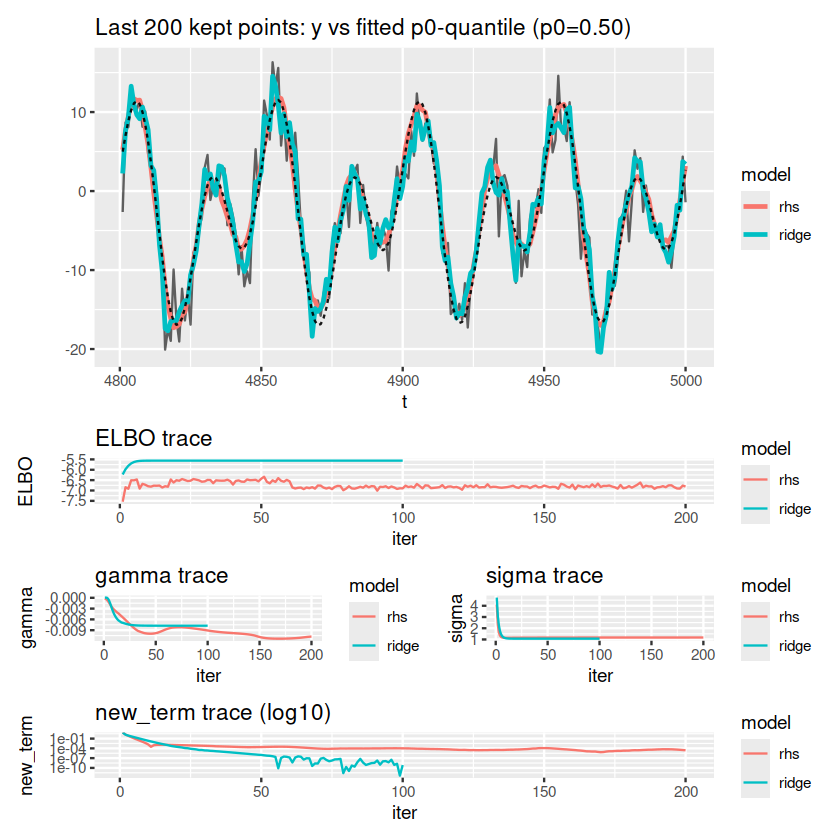

In [ ]:
## ============================================================
## Ridge vs RHS (readout-only) comparison for Q-DESN design
## - shared DESN spec + shared VB config + shared priors on (gamma,sigma)
## - only beta prior differs: ridge vs regularized horseshoe (RHS)
## - outputs: last-200 fit overlay, trace overlays (ELBO/gamma/sigma/new_term),
##            coverage + pinball + MAE/RMSE + corr, plus a compact table
## ============================================================

## ---------------------------
## 0) Packages + options
## ---------------------------
req_pkgs <- c(
  "devtools","ggplot2","dplyr","tidyr","tibble","scales",
  "readr","patchwork"
)
need <- setdiff(req_pkgs, rownames(installed.packages()))
if (length(need)) install.packages(need, dependencies = TRUE)
invisible(lapply(req_pkgs, require, character.only = TRUE))

options(warn = 1)
options(error = function() { traceback(2); stop("Stopped on error (see traceback above).", call. = FALSE) })

`%||%` <- function(x, y) if (!is.null(x)) x else y

## ---------------------------
## 1) Repo load + (optional) namespace patch
## ---------------------------
repo_root <- tryCatch(
  normalizePath(system("git rev-parse --show-toplevel", intern = TRUE)),
  error = function(...) normalizePath("..", mustWork = TRUE)
)

devtools::load_all(repo_root, reset = TRUE)

apply_exdqlm_patch <- function(pkg = "exdqlm") {
  ns <- tryCatch(asNamespace(pkg), error = function(e) NULL)
  if (is.null(ns)) stop("Namespace not available: ", pkg, call. = FALSE)

  .require_fun_fixed <- function(fname, pkg = "exdqlm") {
    stopifnot(is.character(fname), length(fname) == 1L, nzchar(fname))
    ns <- tryCatch(asNamespace(pkg), error = function(e) NULL)
    if (!is.null(ns)) {
      fn <- get0(fname, envir = ns, mode = "function", inherits = FALSE)
      if (!is.null(fn)) return(fn)
    }
    fn <- get0(fname, mode = "function", inherits = TRUE)
    if (!is.null(fn)) return(fn)
    stop(sprintf("Required internal function '%s()' not found.", fname), call. = FALSE)
  }

  .call_with_supported_args_fixed <- function(fn, ...) {
    if (is.character(fn)) fn <- get(fn, mode = "function", inherits = TRUE)
    if (!is.function(fn)) stop("'.call_with_supported_args': fn is not a function.", call. = FALSE)

    dots <- list(...)
    if (!length(dots)) return(do.call(fn, list()))
    nm <- names(dots)
    if (is.null(nm) || any(nm == "")) return(do.call(fn, dots))

    fmls <- names(formals(fn))
    if (is.null(fmls) || "..." %in% fmls) return(do.call(fn, dots))

    keep <- intersect(nm, fmls)
    do.call(fn, dots[keep])
  }

  assignInNamespace(".require_fun", .require_fun_fixed, ns = pkg)
  assignInNamespace(".call_with_supported_args", .call_with_supported_args_fixed, ns = pkg)

  invisible(TRUE)
}
apply_exdqlm_patch()

## ---------------------------
## 2) Verify required functions
## ---------------------------
need_funs <- c("qdesn_build_design","exal_ldvb_fit","beta_prior")
missing <- need_funs[!vapply(need_funs, exists, logical(1), mode="function", inherits=TRUE)]
if (length(missing)) stop("Missing functions: ", paste(missing, collapse=", "), call. = FALSE)

## ---------------------------
## 3) Data (same as your ridge script)
## ---------------------------
data_path <- "/data/muscat_data/jaguir26/exdqlm/results/sim_suite_dlm/series/dlm_constV_smallW/series_long.csv"
df_long <- readr::read_csv(data_path, show_col_types = FALSE)

stopifnot(all(c("t","p","y") %in% names(df_long)))
df_y <- df_long %>%
  arrange(t, p) %>%
  group_by(t) %>%
  summarise(
    y = dplyr::first(y),
    mu_true = if ("mu" %in% names(df_long)) dplyr::first(mu) else NA_real_,
    .groups = "drop"
  ) %>%
  arrange(t)

y <- df_y$y
T <- length(y)
cat("T =", T, "\n")

## ---------------------------
## 4) Shared model settings (p0, bounds, priors on gamma/sigma)
## ---------------------------
p0 <- 0.5

gamma_bounds <- if (exists("L.fn", mode="function", inherits=TRUE) &&
                    exists("U.fn", mode="function", inherits=TRUE)) {
  c(L.fn(p0), U.fn(p0))
} else {
  c(-30, 30)
}

prior_gamma <- list(mu0 = 0, s20 = 1e6)
prior_sigma <- list(a = 1e-6, b = 1e-6)

## ---------------------------
## 5) Shared VB control
## ---------------------------
vb_control <- list(
  max_iter = 200L,
  tol      = 1e-4,
  tol_par  = 1e-4,
  min_iter_elbo = 100L,
  verbose  = TRUE
)

## ---------------------------
## 6) Shared DESN design specification (build ONCE)
## ---------------------------
set.seed(12345)
desn_args <- list(
  D = 3L,
  n = c(500L, 500L, 500L),
  n_tilde = c(500L, 500L),
  m = 120L,
  alpha = 0.15,
  rho = rep(0.95, 3L),
  act_f = "tanh",
  act_k = "identity",
  pi_w = 0.1,
  pi_in = 0.1,
  washout = 500L,
  add_bias = TRUE,
  seed = 12345,
  fit_readout = FALSE
)

des <- qdesn_build_design(y = y, desn_args = desn_args)
X <- des$X
keep_idx <- des$keep_idx
y_fit <- y[keep_idx]
mu_true_keep <- df_y$mu_true[keep_idx]

cat("Design dim:", paste(dim(X), collapse="x"), " y_fit:", length(y_fit), "\n")
stopifnot(nrow(X) == length(y_fit))

## ---------------------------
## 7) Beta priors (ONLY difference)
## ---------------------------
beta_prior_ridge_obj <- beta_prior("ridge", ridge = list(tau2 = 1e8))

rhs_hypers <- list(
  tau0 = 1.0,
  nu   = 4.0,
  s    = 1.0,
  shrink_intercept = FALSE,
  intercept_prec   = 1e-24,
  n_inner = 1L,
  eta_bounds = list(lambda = c(-22,22), tau = c(-22,22), c2 = c(-22,22)),
  h_curv = 1e-24,
  var_floor = 1e-24,
  verbose = TRUE
)
beta_prior_rhs_obj <- beta_prior("rhs", rhs = rhs_hypers)

## ---------------------------
## 8) Fit helper
## ---------------------------
fit_readout <- function(beta_prior_obj, label) {
  fit <- exal_ldvb_fit(
    y = y_fit,
    X = X,
    p0 = p0,
    gamma_bounds = gamma_bounds,
    vb_control   = vb_control,
    init         = list(),
    prior_gamma  = prior_gamma,
    prior_sigma  = prior_sigma,
    beta_prior_obj = beta_prior_obj
  )

  elbo <- fit$misc$elbo_trace %||% fit$misc$elbo
  df_tr <- tibble(
    model = label,
    iter = seq_along(elbo),
    elbo = as.numeric(elbo),
    gamma = as.numeric(fit$misc$gamma_trace %||% rep(NA_real_, length(elbo))),
    sigma = as.numeric(fit$misc$sigma_trace %||% rep(NA_real_, length(elbo))),
    new_term = as.numeric(fit$misc$new_term_trace %||% rep(NA_real_, length(elbo)))
  )

  beta_hat <- as.numeric(fit$qbeta$m)
  mu_hat <- as.numeric(X %*% beta_hat)

  df_fit <- tibble(
    model = label,
    t = keep_idx,
    y = y_fit,
    mu_hat = mu_hat,
    mu_true = mu_true_keep
  )

  list(fit = fit, df_tr = df_tr, df_fit = df_fit, beta_hat = beta_hat)
}

## ---------------------------
## 9) Fit both models
## ---------------------------
ridge <- fit_readout(beta_prior_ridge_obj, "ridge")
rhs   <- fit_readout(beta_prior_rhs_obj,   "rhs")

cat("\nRidge converged:", ridge$fit$converged, " iter:", ridge$fit$iter, " time:", ridge$fit$run.time, "sec\n")
cat("  gamma_hat:", ridge$fit$qsiggam$gamma_mean, " sigma_hat:", ridge$fit$qsiggam$sigma_mean, "\n")
cat("RHS converged:", rhs$fit$converged, " iter:", rhs$fit$iter, " time:", rhs$fit$run.time, "sec\n")
cat("  gamma_hat:", rhs$fit$qsiggam$gamma_mean, " sigma_hat:", rhs$fit$qsiggam$sigma_mean, "\n")

## ---------------------------
## 10) Metrics helpers
## ---------------------------
check_loss <- function(u, p) u * (p - as.numeric(u < 0))

metrics_block <- function(df, p) {
  u <- df$y - df$mu_hat
  tibble(
    n = nrow(df),
    MAE = mean(abs(u)),
    RMSE = sqrt(mean(u^2)),
    pinball = mean(check_loss(u, p)),
    coverage = mean(df$y <= df$mu_hat),
    corr = suppressWarnings(cor(df$y, df$mu_hat))
  )
}

dist_to_bounds <- function(fit, bounds) {
  L <- bounds[1]; U <- bounds[2]
  g <- fit$qsiggam$gamma_mean %||% NA_real_
  if (!is.finite(g)) return(NA_real_)
  min(g - L, U - g)
}

## ---------------------------
## 11) Build comparison frames (last 200 only)
## ---------------------------
n_last <- 200L
df_fit_all  <- bind_rows(ridge$df_fit, rhs$df_fit)
df_fit_last <- df_fit_all %>%
  group_by(model) %>%
  slice_tail(n = n_last) %>%
  ungroup()

df_tr_all <- bind_rows(ridge$df_tr, rhs$df_tr)

## ---------------------------
## 12) Metrics tables (all kept + last 200)
## ---------------------------
tab_all <- df_fit_all %>%
  group_by(model) %>%
  group_modify(~ metrics_block(.x, p0)) %>%
  ungroup() %>%
  mutate(
    gamma_hat = c(ridge$fit$qsiggam$gamma_mean, rhs$fit$qsiggam$gamma_mean),
    sigma_hat = c(ridge$fit$qsiggam$sigma_mean, rhs$fit$qsiggam$sigma_mean),
    dist_to_gamma_bounds = c(dist_to_bounds(ridge$fit, gamma_bounds), dist_to_bounds(rhs$fit, gamma_bounds)),
    elbo_last = c(tail(ridge$df_tr$elbo, 1), tail(rhs$df_tr$elbo, 1))
  )

tab_last <- df_fit_last %>%
  group_by(model) %>%
  group_modify(~ metrics_block(.x, p0)) %>%
  ungroup()

cat("\n=== Metrics: ALL kept ===\n"); print(tab_all)
cat("\n=== Metrics: LAST 200 kept ===\n"); print(tab_last)

## ---------------------------
## 13) Plots: last-200 fit overlay (ridge vs rhs)
## ---------------------------
df_last_wide <- df_fit_last %>%
  select(model, t, y, mu_hat, mu_true)

p_fit_last <- ggplot() +
  geom_line(data = df_last_wide %>% distinct(t, y), aes(t, y), alpha = 0.6) +
  geom_line(data = df_last_wide, aes(t, mu_hat, color = model), linewidth = 1) +
  { if (any(is.finite(df_last_wide$mu_true)))
      geom_line(data = df_last_wide %>% distinct(t, mu_true),
                aes(t, mu_true), linetype = 2, alpha = 0.9) } +
  labs(
    title = sprintf("Last %d kept points: y vs fitted p0-quantile (p0=%.2f)", n_last, p0),
    x = "t", y = ""
  )

## ---------------------------
## 14) Plots: traces overlay (ELBO/gamma/sigma/new_term)
## ---------------------------
p_elbo <- ggplot(df_tr_all, aes(iter, elbo, color = model)) +
  geom_line() + labs(title = "ELBO trace", x = "iter", y = "ELBO")

p_gamma <- ggplot(df_tr_all, aes(iter, gamma, color = model)) +
  geom_line() + labs(title = "gamma trace", x = "iter", y = "gamma")

p_sigma <- ggplot(df_tr_all, aes(iter, sigma, color = model)) +
  geom_line() + labs(title = "sigma trace", x = "iter", y = "sigma")

p_new <- ggplot(df_tr_all, aes(iter, pmax(new_term, 1e-16), color = model)) +
  geom_line() +
  scale_y_log10(labels = label_scientific()) +
  labs(title = "new_term trace (log10)", x = "iter", y = "new_term")

## ---------------------------
## 15) Show plots (no full-series plot)
## ---------------------------
(p_fit_last) / (p_elbo / (p_gamma | p_sigma) / p_new)

## ---------------------------
## 16) Optional: beta magnitude quick comparison
## ---------------------------
beta_stats <- tibble(
  model = c("ridge","rhs"),
  p = length(ridge$beta_hat),
  l1 = c(sum(abs(ridge$beta_hat)), sum(abs(rhs$beta_hat))),
  l2 = c(sqrt(sum(ridge$beta_hat^2)), sqrt(sum(rhs$beta_hat^2))),
  max_abs = c(max(abs(ridge$beta_hat)), max(abs(rhs$beta_hat))),
  n_gt_1e_2 = c(sum(abs(ridge$beta_hat) > 1e-2), sum(abs(rhs$beta_hat) > 1e-2)),
  n_gt_1e_1 = c(sum(abs(ridge$beta_hat) > 1e-1), sum(abs(rhs$beta_hat) > 1e-1))
)
cat("\n=== Beta magnitude summary ===\n"); print(beta_stats)
